# Week 3

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from datetime import datetime, time

In [146]:
data = pd.read_csv(r"G:\My Drive\Skole\DTU\10. semester\02806 Social_data_viz\10_sem\Lectures\Data\2003_2026.csv")

In [147]:
data.head(2)

,Incident Category,Incident Datetime,Incident Day of Week,Incident Code,Incident Description,Police District,Longitude,Latitude
0,Robbery,2004-11-22 17:50:00,Monday,3074,"ROBBERY, BODILY FORCE",Ingleside,-122.420084,37.708311
1,Motor Vehicle Theft,2005-10-18 20:00:00,Tuesday,7021,STOLEN AUTOMOBILE,Park,-120.500000,90.000000


## Part 2

### Exercise 2.1

In [148]:
hoods = data['Police District'].unique()
print(hoods)
print(len(hoods))

['Ingleside' 'Park' 'Southern' 'Taraval' 'Tenderloin' 'Bayview' 'Central'
 'Northern' 'Mission' 'Richmond' 'Out of SF']
11


Incidents in each police district

In [149]:
data['Police District'].value_counts()

Police District
Southern      513027
Mission       414786
Northern      399201
Central       363735
Bayview       294441
Tenderloin    289161
Ingleside     257450
Taraval       226075
Richmond      172359
Park          163926
Out of SF      32679
Name: count, dtype: int64

In [150]:
focus_crimes = ['Robbery','Motor Vehicle Theft','Weapons Offense','Rape','Disorderly Conduct','Larceny Theft']

In [151]:
focus_data = data[data['Incident Category'].isin(focus_crimes)]

Incidents in each district focus on the focus crimes

In [152]:
district_focus_counts = focus_data['Police District'][focus_data['Incident Category'].isin(focus_crimes)].value_counts()
district_focus_counts

Police District
Southern      185862
Northern      170951
Central       161813
Mission       129403
Bayview        89275
Ingleside      87061
Taraval        81705
Richmond       72331
Tenderloin     62003
Park           57831
Out of SF       5134
Name: count, dtype: int64

Count of focus crimes in each police district. 

In [153]:
focus_crime_table = pd.crosstab(focus_data['Police District'], focus_data['Incident Category']).sort_values(by='Larceny Theft', ascending=False)
focus_crime_table

Incident Category,Disorderly Conduct,Larceny Theft,Motor Vehicle Theft,Rape,Robbery,Weapons Offense
Police District,,,,,,
Southern,4702,145929,17083,1760,11921,4467
Northern,3928,133283,20747,1021,8950,3022
Central,3137,132823,14198,924,8295,2436
Mission,5811,79640,24474,1569,12398,5511
Richmond,1054,54425,12791,413,2666,982
Taraval,1651,53776,19393,644,4396,1845
Bayview,2703,44914,26061,679,8575,6343
Ingleside,1790,43511,28430,846,8489,3995
Park,1220,40165,12259,452,2623,1112


In [154]:
total_focus_crimes = focus_data['Incident Category'].value_counts()
total_focus_crimes

Incident Category
Larceny Theft          771237
Motor Vehicle Theft    181131
Robbery                 76951
Weapons Offense         34127
Disorderly Conduct      30913
Rape                     9010
Name: count, dtype: int64

In [155]:
# Calculate probability by dividing by the total sum
crime_probabilities = total_focus_crimes / total_focus_crimes.sum()*100
print(crime_probabilities)

Incident Category
Larceny Theft          69.898375
Motor Vehicle Theft    16.416176
Robbery                 6.974185
Weapons Offense         3.092982
Disorderly Conduct      2.801692
Rape                    0.816590
Name: count, dtype: float64


In [156]:
district_crime_probs = (
    focus_data
    .groupby('Police District')['Incident Category']
    .value_counts(normalize=True)
)
district_crime_probs

Police District  Incident Category  
Bayview          Larceny Theft          0.503097
                 Motor Vehicle Theft    0.291918
                 Robbery                0.096052
                 Weapons Offense        0.071050
                 Disorderly Conduct     0.030277
                                          ...   
Tenderloin       Robbery                0.135622
                 Motor Vehicle Theft    0.080238
                 Disorderly Conduct     0.076819
                 Weapons Offense        0.065529
                 Rape                   0.011080
Name: proportion, Length: 66, dtype: float64

In [157]:
# Turn the result into a nice matrix/table
prob_matrix = district_crime_probs.unstack()
print(prob_matrix)

Incident Category  Disorderly Conduct  Larceny Theft  Motor Vehicle Theft  \
Police District                                                             
Bayview                      0.030277       0.503097             0.291918   
Central                      0.019387       0.820843             0.087743   
Ingleside                    0.020560       0.499776             0.326553   
Mission                      0.044906       0.615442             0.189130   
Northern                     0.022977       0.779656             0.121362   
Out of SF                    0.029996       0.713868             0.140242   
Park                         0.021096       0.694524             0.211980   
Richmond                     0.014572       0.752444             0.176840   
Southern                     0.025298       0.785147             0.091912   
Taraval                      0.020207       0.658173             0.237354   
Tenderloin                   0.076819       0.630711             0.080238   

LETS PLOT MAN

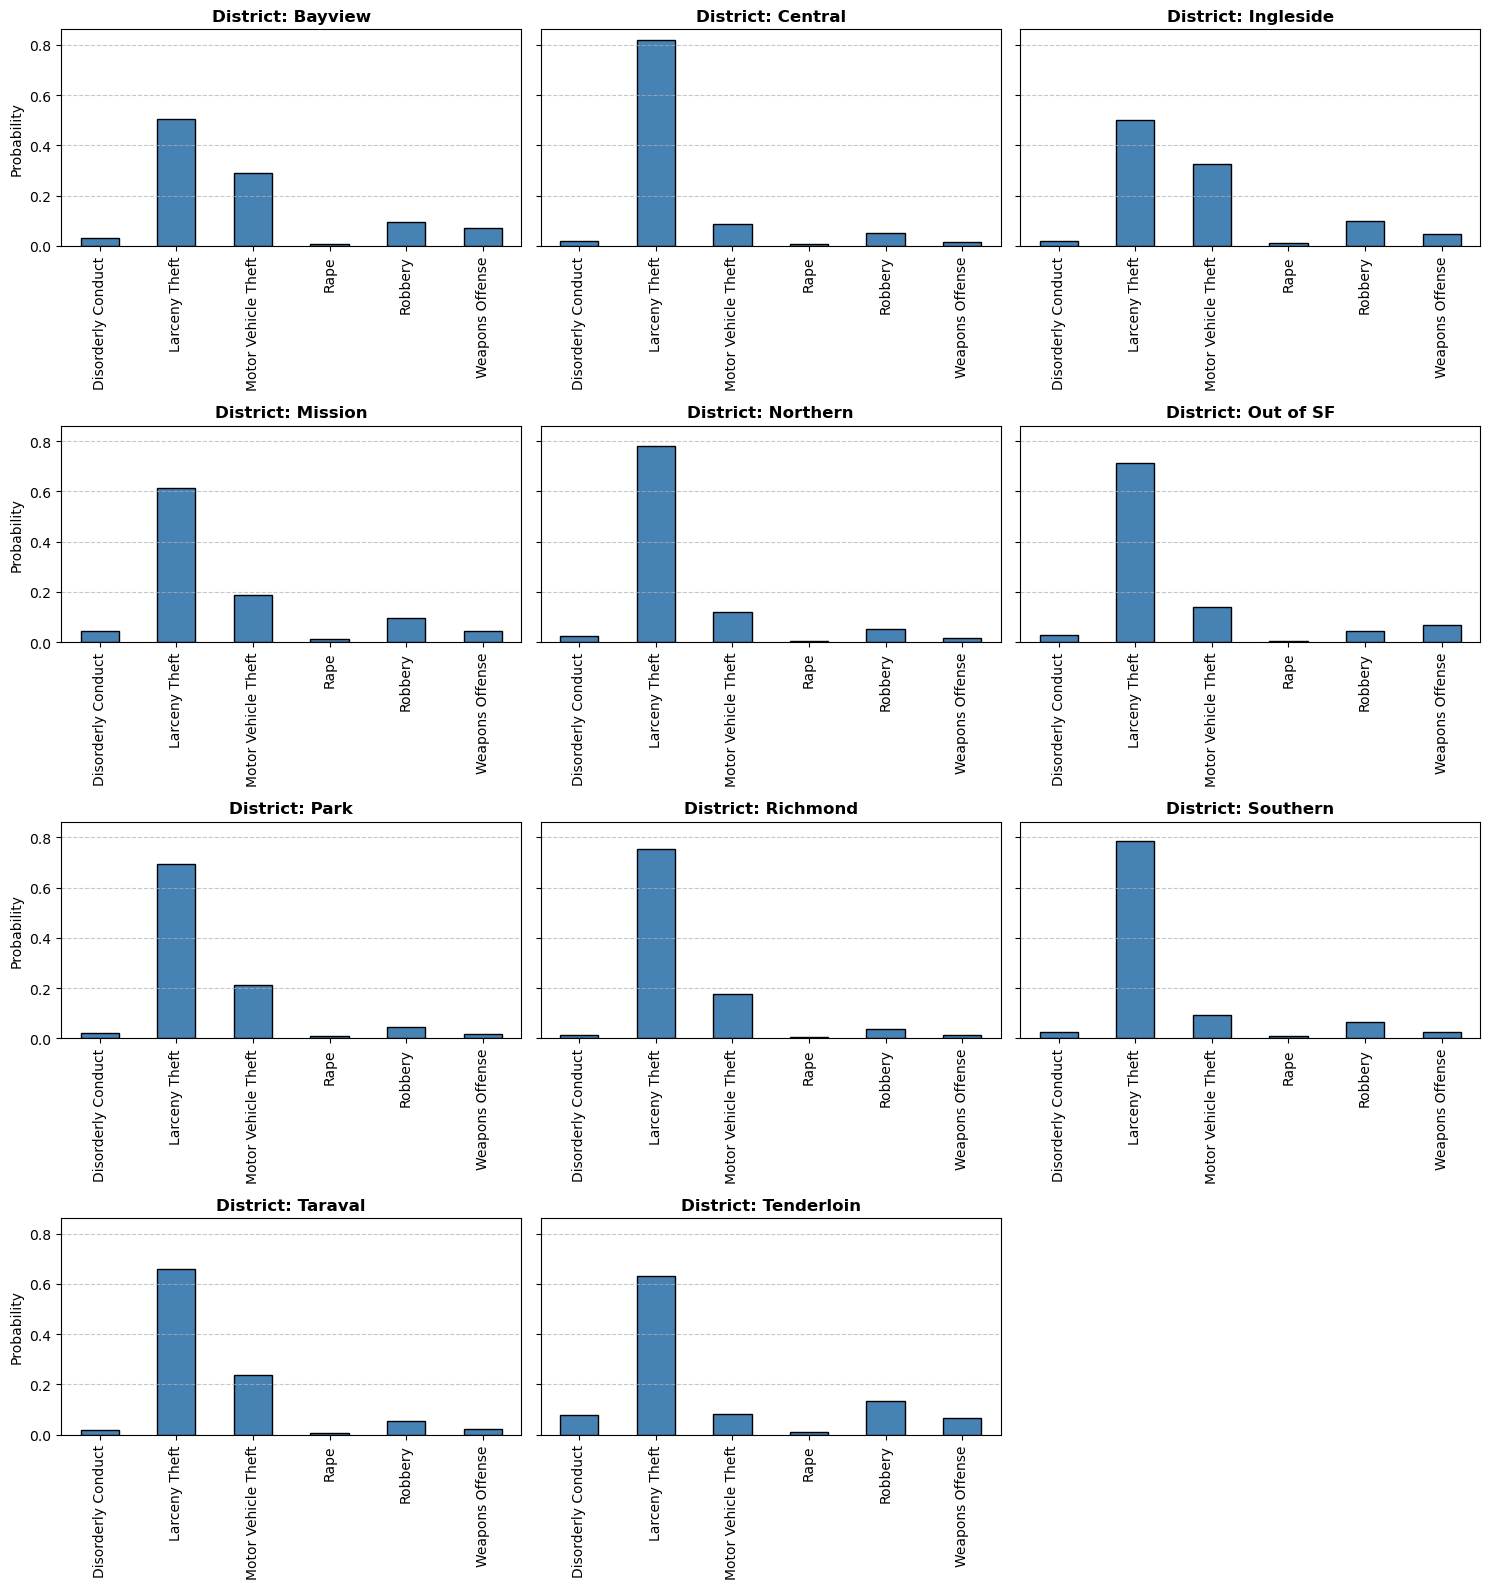

In [158]:
import matplotlib.pyplot as plt

# 1. Prepare the data (assuming you have focus_crimes list and focus_data)
prob_matrix = (
    focus_data
    .groupby('Police District')['Incident Category']
    .value_counts(normalize=True)
    .unstack()
)

# 2. Set up the subplots
# We have 11 districts, so a 4x3 grid (12 slots) works perfectly
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 16), sharey=True)
axes = axes.flatten()  # Flatten the 4x3 grid into a 1D list for easy looping

# 3. Loop through each district and plot
for i, district in enumerate(prob_matrix.index):
    ax = axes[i]
    prob_matrix.loc[district].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    
    # Customizing each subplot
    ax.set_title(f"District: {district}", fontsize=12, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Probability")
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Hide the 12th subplot (since we only have 11 districts)
if len(prob_matrix) < len(axes):
    axes[-1].axis('off')

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()

In [159]:
crime_ratio = prob_matrix / crime_probabilities *100
crime_ratio

Incident Category,Disorderly Conduct,Larceny Theft,Motor Vehicle Theft,Rape,Robbery,Weapons Offense
Police District,,,,,,
Bayview,1.080677,0.719755,1.778235,0.931399,1.377244,2.297140
Central,0.691960,1.174337,0.534493,0.699286,0.735037,0.486728
Ingleside,0.733853,0.715004,1.989213,1.189988,1.398104,1.483596
Mission,1.602825,0.880481,1.152096,1.484823,1.373769,1.376920
Northern,0.820124,1.115414,0.739285,0.731392,0.750685,0.571538
Out of SF,1.070643,1.021295,0.854289,0.357793,0.639567,2.210416
Park,0.752972,0.993619,1.291286,0.957136,0.650345,0.621680
Richmond,0.520111,1.076482,1.077229,0.699232,0.528497,0.438945
Southern,0.902967,1.123269,0.559888,1.159626,0.919663,0.777048


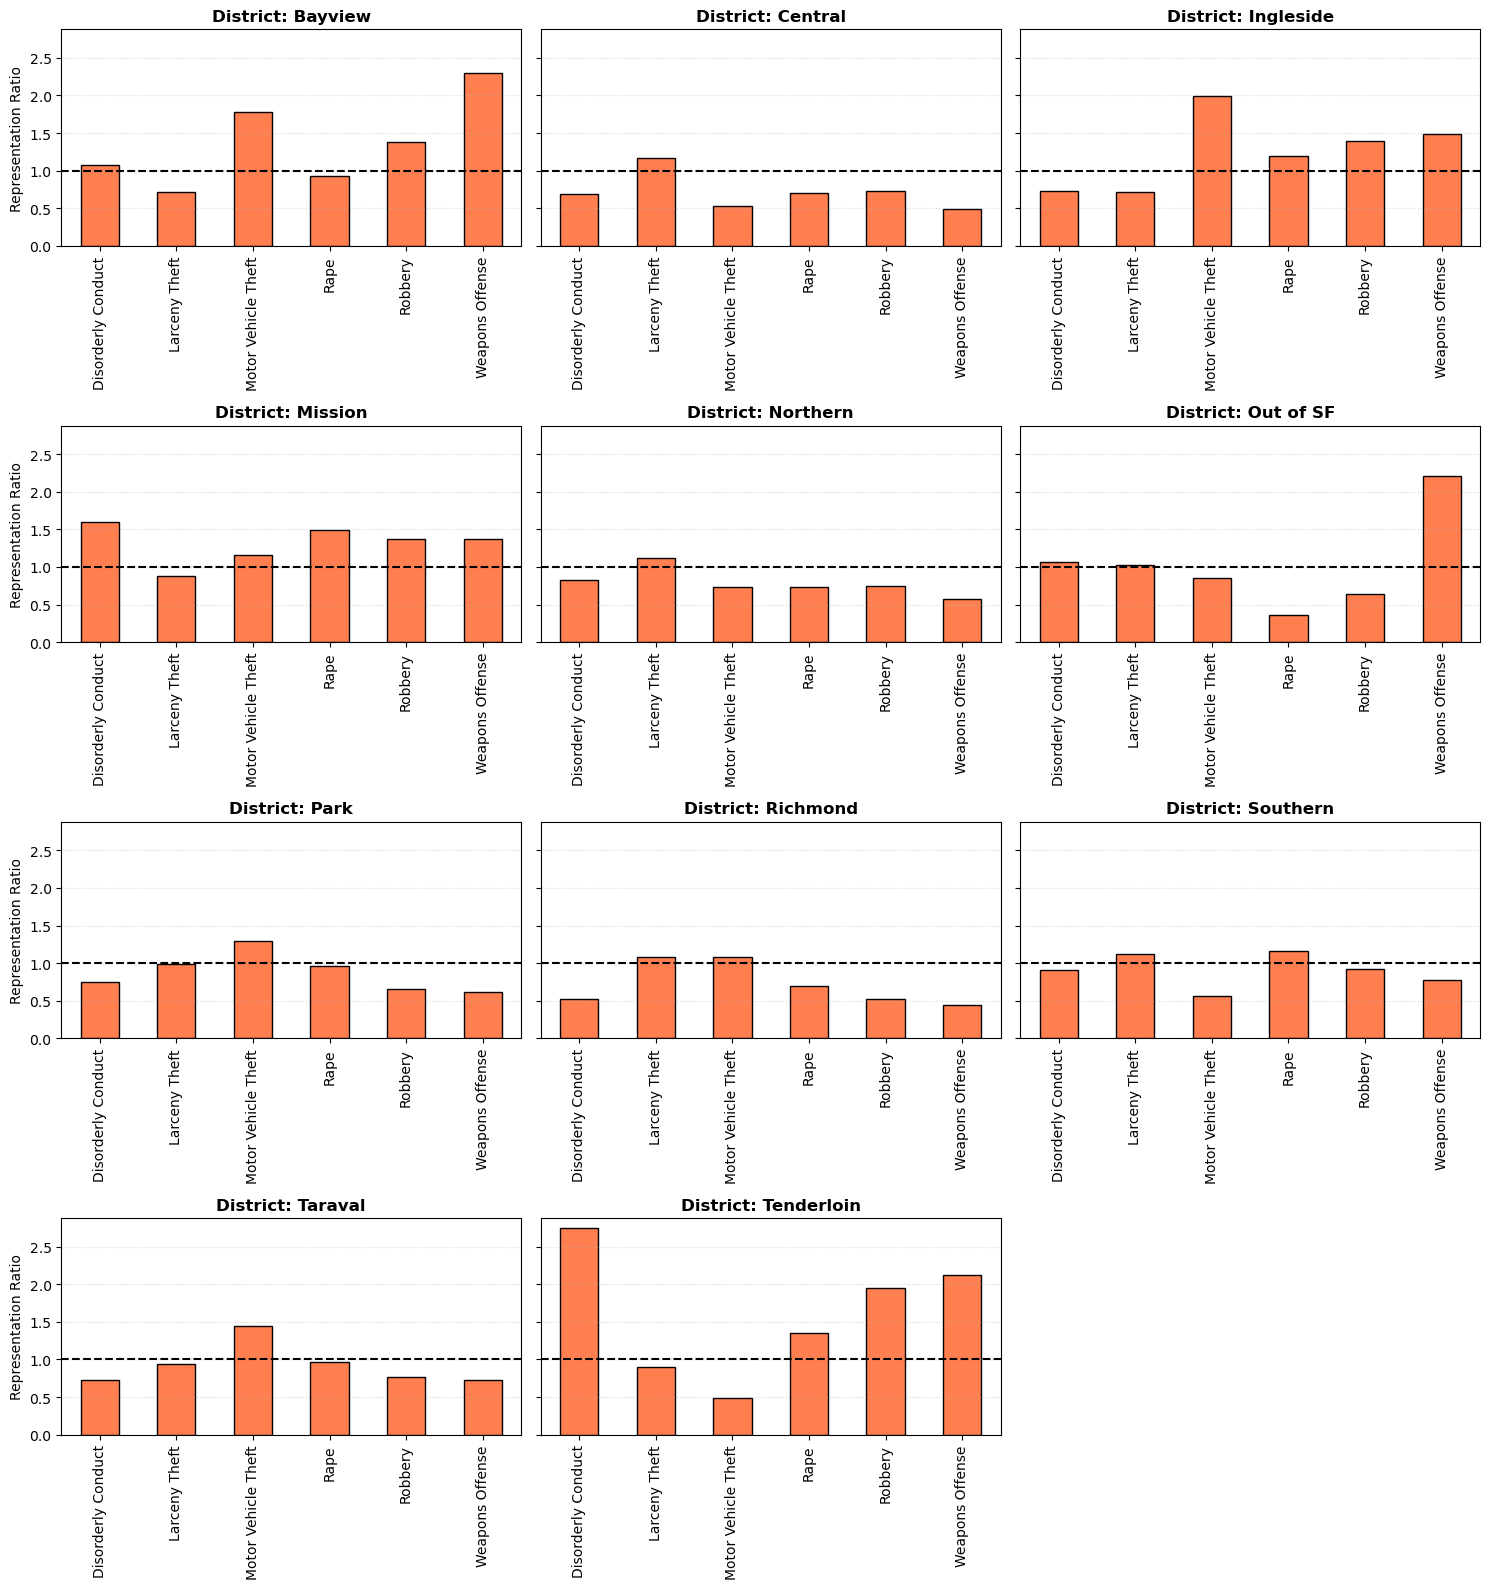

In [160]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 16), sharey=True)
axes = axes.flatten()

for i, district in enumerate(crime_ratio.index):
    ax = axes[i]
    crime_ratio.loc[district].plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    
    # Baseline: The city average (Ratio = 1)
    ax.axhline(1, color='black', linestyle='--', linewidth=1.5, label='City Average')
    
    ax.set_title(f"District: {district}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Representation Ratio")
    ax.set_xlabel("")
    ax.grid(axis='y', linestyle=':', alpha=0.5)

# Clear the empty plot
if len(crime_ratio) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

## Exercise 2.2

In [161]:
early_years = [2003, 2004, 2005, 2006, 2007, 2008]
late_years = [2020, 2021, 2022, 2023, 2024, 2025]

In [162]:
focus_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1103369 entries, 0 to 3126837
Data columns (total 8 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Incident Category     1103369 non-null  object 
 1   Incident Datetime     1103369 non-null  object 
 2   Incident Day of Week  1103369 non-null  object 
 3   Incident Code         1103369 non-null  int64  
 4   Incident Description  1103369 non-null  object 
 5   Police District       1103369 non-null  object 
 6   Longitude             1075084 non-null  float64
 7   Latitude              1075084 non-null  float64
dtypes: float64(2), int64(1), object(5)
memory usage: 75.8+ MB


In [163]:
# Convert the Incident Datetime column to datetimelike values
focus_data['Incident Datetime'] = pd.to_datetime(focus_data['Incident Datetime'])


C:\Users\victo\AppData\Local\Temp\ipykernel_30328\1281155846.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  focus_data['Incident Datetime'] = pd.to_datetime(focus_data['Incident Datetime'])


In [164]:
early = focus_data[focus_data['Incident Datetime'].dt.year.isin(early_years)]
early.describe()

,Incident Datetime,Incident Code,Longitude,Latitude
count,263111,263111.000000,263111.000000,263111.000000
mean,2005-11-07 17:25:50.953399936,6863.384051,-122.424137,37.778450
min,2003-01-01 00:01:00,2001.000000,-122.513642,37.707920
25%,2004-05-21 13:00:00,6243.000000,-122.435252,37.753967
50%,2005-09-26 09:56:00,6304.000000,-122.418401,37.775421
75%,2007-05-04 15:11:30,7021.000000,-122.406691,37.785951
max,2008-12-31 23:55:00,30140.000000,-120.500000,90.000000
std,NaN,3282.483505,0.037139,0.720370


In [165]:
late = focus_data[focus_data['Incident Datetime'].dt.year.isin(late_years)]
late.describe()

,Incident Datetime,Incident Code,Longitude,Latitude
count,278761,278761.000000,260199.000000,260199.000000
mean,2022-10-19 11:50:01.599219456,9845.173719,-122.426203,37.769238
min,2020-01-01 00:00:00,2002.000000,-122.511940,37.707848
25%,2021-07-14 17:00:00,6244.000000,-122.437798,37.752628
50%,2022-10-05 22:00:00,6360.000000,-122.419579,37.775627
75%,2023-12-31 03:26:00,7021.000000,-122.407692,37.786613
max,2025-12-31 23:57:00,71013.000000,-122.366287,37.830055
std,NaN,13148.527130,0.027436,0.025436


In [166]:
total_focus_crimes_early = early['Incident Category'].value_counts()
print(total_focus_crimes_early)

total_focus_crimes_late = late['Incident Category'].value_counts()
print(total_focus_crimes_late)

Incident Category
Larceny Theft          154210
Motor Vehicle Theft     70944
Robbery                 22009
Weapons Offense          7507
Disorderly Conduct       5851
Rape                     2590
Name: count, dtype: int64
Incident Category
Larceny Theft          195513
Motor Vehicle Theft     44183
Robbery                 15461
Disorderly Conduct      13327
Weapons Offense         10097
Rape                      180
Name: count, dtype: int64


In [167]:
# Calculate probability by dividing by the total sum
crime_probabilities_early = total_focus_crimes_early / total_focus_crimes_early.sum()*100
print(crime_probabilities_early)

# Calculate probability by dividing by the total sum
crime_probabilities_late = total_focus_crimes_late / total_focus_crimes_late.sum()*100
print(crime_probabilities_late)

Incident Category
Larceny Theft          58.610244
Motor Vehicle Theft    26.963525
Robbery                 8.364911
Weapons Offense         2.853168
Disorderly Conduct      2.223776
Rape                    0.984375
Name: count, dtype: float64
Incident Category
Larceny Theft          70.136425
Motor Vehicle Theft    15.849778
Robbery                 5.546328
Disorderly Conduct      4.780798
Weapons Offense         3.622099
Rape                    0.064571
Name: count, dtype: float64


In [168]:
district_crime_probs_early = (
    early
    .groupby('Police District')['Incident Category']
    .value_counts(normalize=True)
)
district_crime_probs_early

Police District  Incident Category  
Bayview          Larceny Theft          0.394443
                 Motor Vehicle Theft    0.393921
                 Robbery                0.126372
                 Weapons Offense        0.062054
                 Disorderly Conduct     0.013674
                 Rape                   0.009537
Central          Larceny Theft          0.710636
                 Motor Vehicle Theft    0.185834
                 Robbery                0.058998
                 Disorderly Conduct     0.021844
                 Weapons Offense        0.013977
                 Rape                   0.008711
Ingleside        Motor Vehicle Theft    0.459475
                 Larceny Theft          0.359239
                 Robbery                0.115459
                 Weapons Offense        0.045754
                 Rape                   0.012103
                 Disorderly Conduct     0.007970
Mission          Larceny Theft          0.503590
                 Motor Vehicle T

In [169]:
district_crime_probs_late = (
    late
    .groupby('Police District')['Incident Category']
    .value_counts(normalize=True)
)
district_crime_probs_late

Police District  Incident Category  
Bayview          Larceny Theft          0.485631
                 Motor Vehicle Theft    0.313209
                 Weapons Offense        0.073002
                 Robbery                0.066625
                 Disorderly Conduct     0.060704
                                          ...   
Tenderloin       Disorderly Conduct     0.127537
                 Motor Vehicle Theft    0.125443
                 Robbery                0.122652
                 Weapons Offense        0.094679
                 Rape                   0.001512
Name: proportion, Length: 66, dtype: float64

In [170]:
# Turn the result into a nice matrix/table
prob_matrix_early = district_crime_probs_early.unstack()
print(prob_matrix_early)

Incident Category  Disorderly Conduct  Larceny Theft  Motor Vehicle Theft  \
Police District                                                             
Bayview                      0.013674       0.394443             0.393921   
Central                      0.021844       0.710636             0.185834   
Ingleside                    0.007970       0.359239             0.459475   
Mission                      0.044504       0.503590             0.300064   
Northern                     0.020402       0.682642             0.207852   
Park                         0.021881       0.525684             0.360307   
Richmond                     0.008454       0.548026             0.367302   
Southern                     0.025966       0.740003             0.132492   
Taraval                      0.011312       0.489418             0.398467   
Tenderloin                   0.036401       0.653013             0.098874   

Incident Category      Rape   Robbery  Weapons Offense  
Police District   

In [171]:
prob_matrix_late = district_crime_probs_late.unstack()
print(prob_matrix_late)

Incident Category  Disorderly Conduct  Larceny Theft  Motor Vehicle Theft  \
Police District                                                             
Bayview                      0.060704       0.485631             0.313209   
Central                      0.028516       0.841895             0.067044   
Ingleside                    0.038839       0.564153             0.283405   
Mission                      0.062732       0.621912             0.181375   
Northern                     0.036490       0.790651             0.110276   
Out of SF                    0.031360       0.691268             0.155718   
Park                         0.030419       0.770673             0.162064   
Richmond                     0.025932       0.819452             0.116253   
Southern                     0.064012       0.693769             0.145351   
Taraval                      0.035526       0.709673             0.198228   
Tenderloin                   0.127537       0.528177             0.125443   

In [172]:
crime_ratio_early = prob_matrix_early / crime_probabilities_early *100
crime_ratio_early

Incident Category,Disorderly Conduct,Larceny Theft,Motor Vehicle Theft,Rape,Robbery,Weapons Offense
Police District,,,,,,
Bayview,0.614881,0.672994,1.460940,0.968804,1.510736,2.174903
Central,0.982280,1.212477,0.689205,0.884975,0.705298,0.489890
Ingleside,0.358398,0.612929,1.704063,1.229465,1.380280,1.603605
Mission,2.001301,0.859218,1.112850,1.181097,1.275978,1.173488
Northern,0.917428,1.164715,0.770863,0.668071,0.764143,0.652188
Park,0.983968,0.896915,1.336275,0.989442,0.701013,0.832379
Richmond,0.380172,0.935035,1.362217,0.786167,0.607181,0.619969
Southern,1.167659,1.262584,0.491376,1.145401,0.864859,0.628022
Taraval,0.508675,0.835038,1.477802,0.898920,0.800470,0.876059


In [173]:
crime_ratio_late = prob_matrix_late / crime_probabilities_late *100
crime_ratio_late

Incident Category,Disorderly Conduct,Larceny Theft,Motor Vehicle Theft,Rape,Robbery,Weapons Offense
Police District,,,,,,
Bayview,1.269745,0.692410,1.976110,1.282544,1.201250,2.015463
Central,0.596467,1.200368,0.422997,0.621536,0.786063,0.512021
Ingleside,0.812398,0.804365,1.788072,0.597507,1.237448,1.230875
Mission,1.312161,0.886718,1.144340,0.973457,1.490879,1.398723
Northern,0.763257,1.127304,0.695758,0.749668,0.755993,0.556850
Out of SF,0.655954,0.985605,0.982460,5.024079,0.760387,2.104769
Park,0.636282,1.098820,1.022503,0.686063,0.423326,0.356723
Richmond,0.542426,1.168368,0.733468,0.216305,0.512887,0.269926
Southern,1.338940,0.989170,0.917055,1.721422,1.010309,1.096642


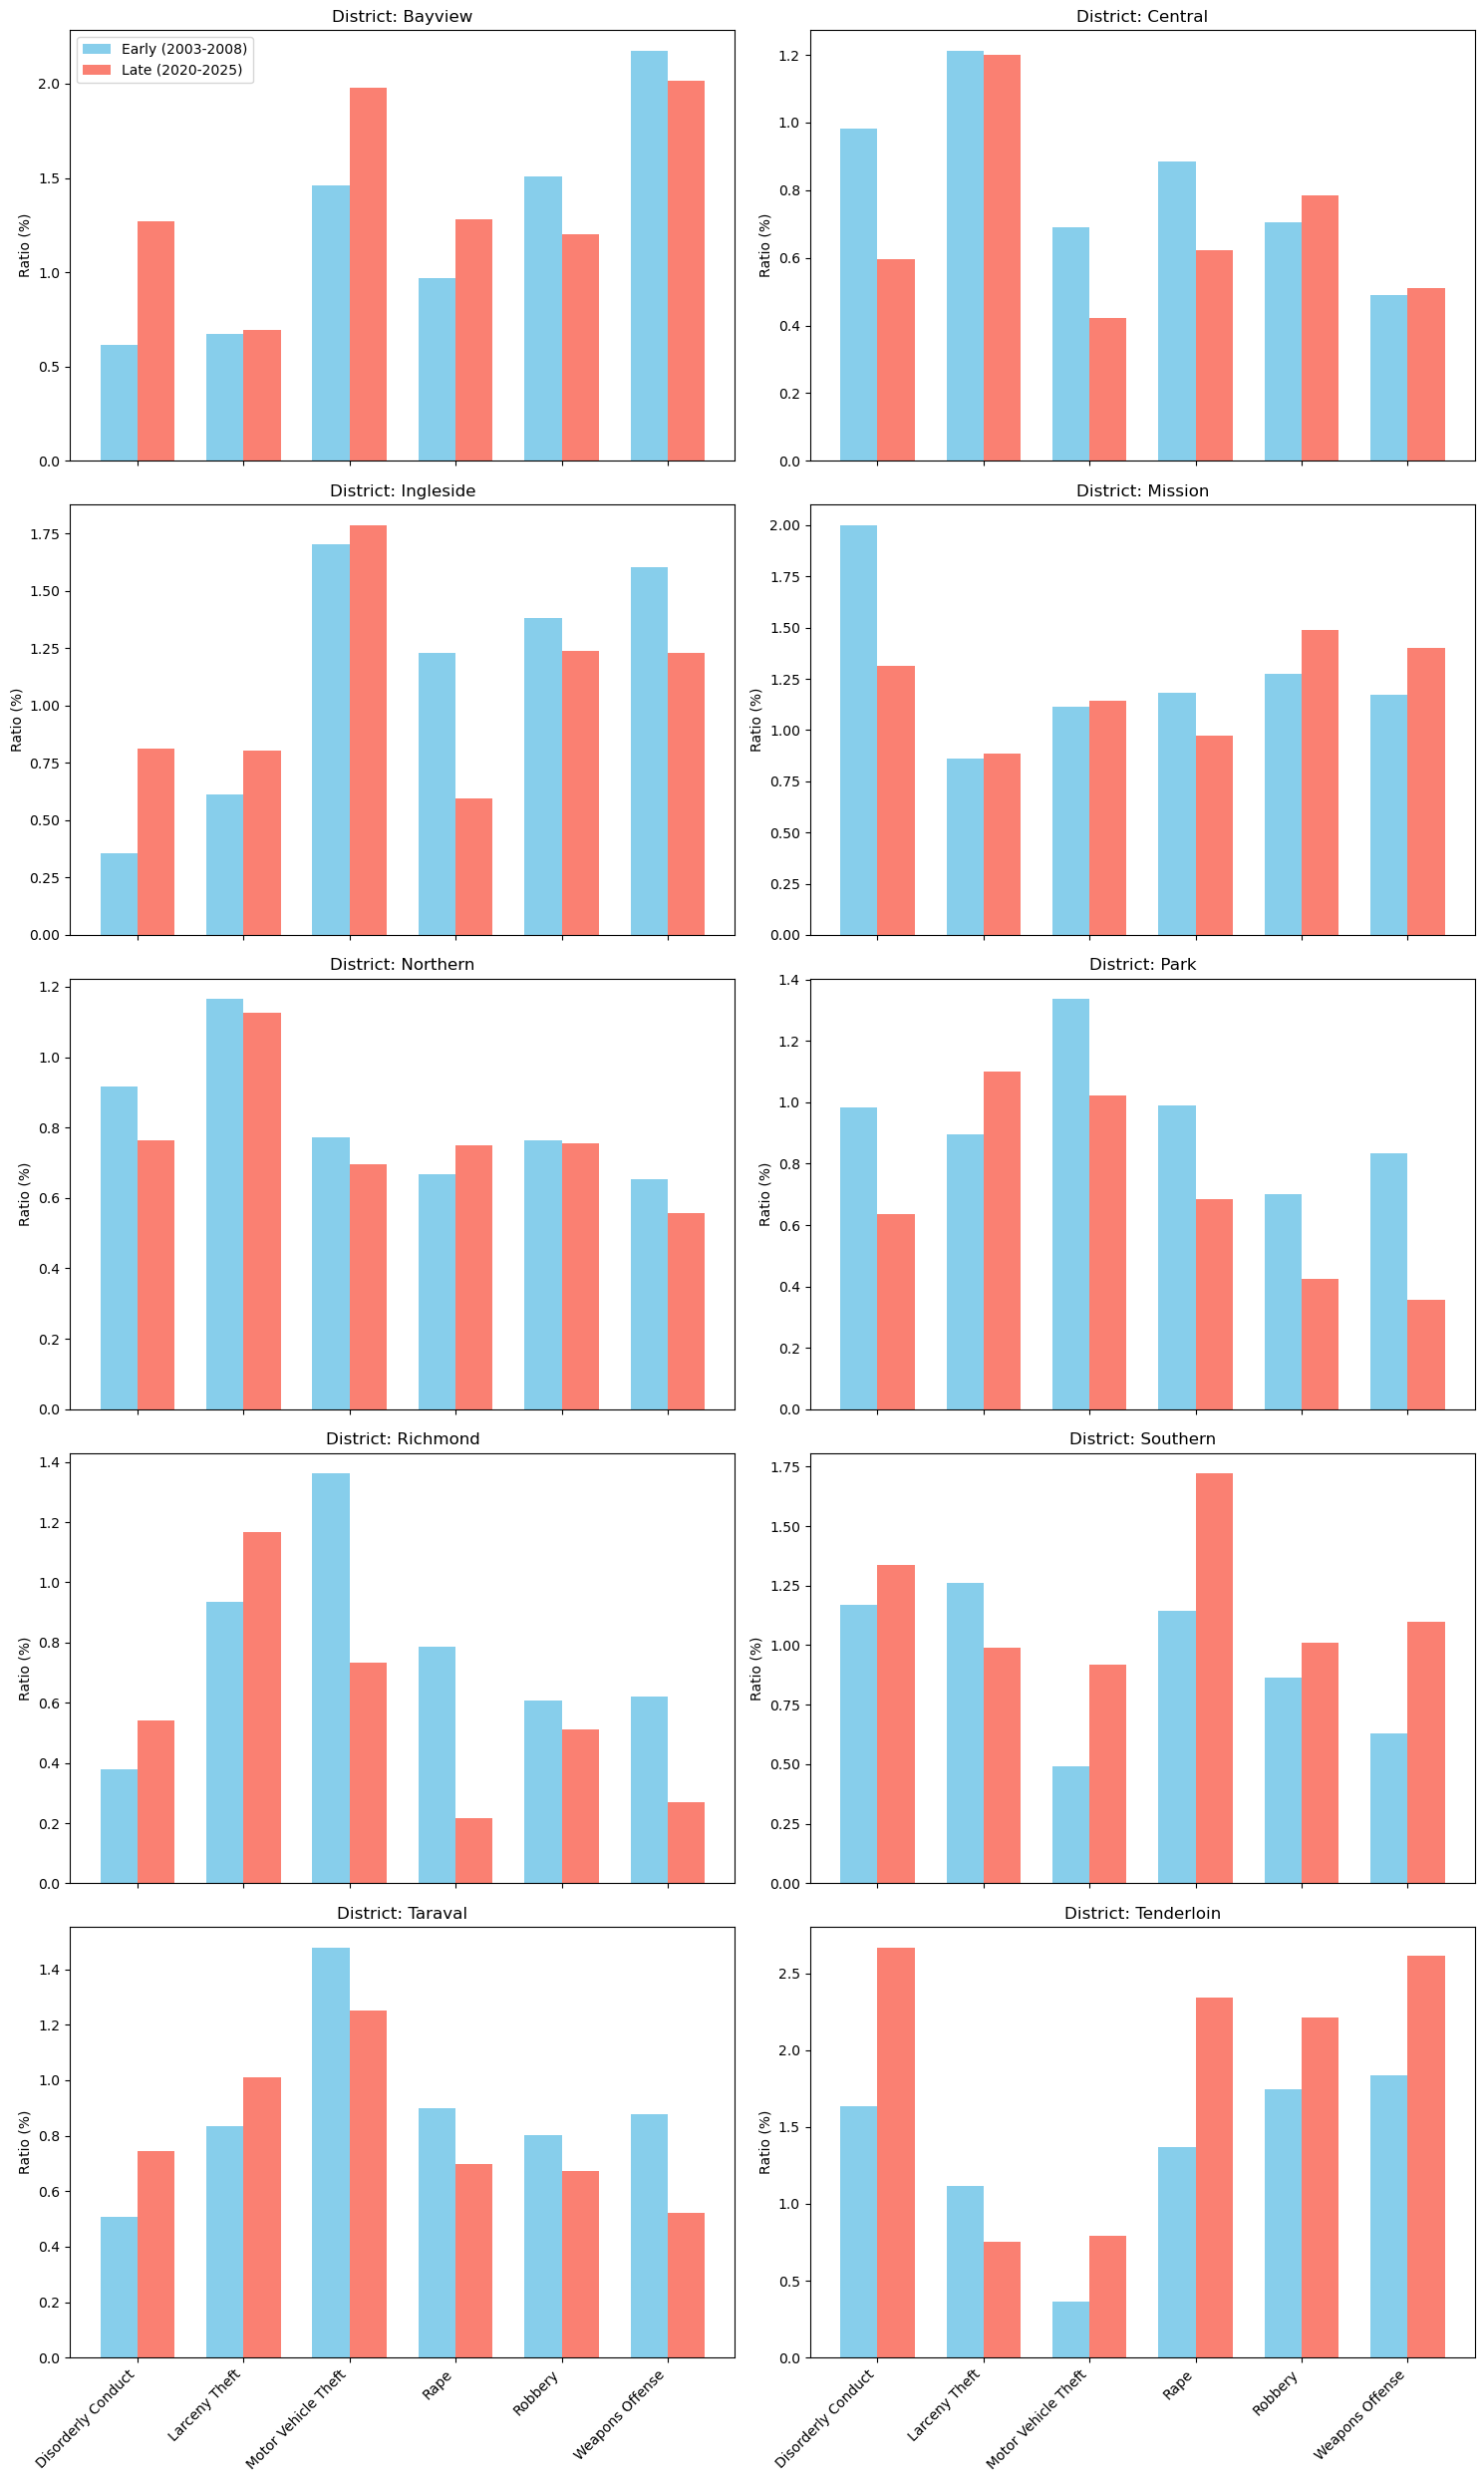

In [174]:
# Assuming crime_ratio_early and crime_ratio_late are DataFrames
# with Districts as index and Crime Categories as columns.

districts = crime_ratio_early.index.tolist()
focus_crimes = crime_ratio_early.columns.tolist()

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 25), sharex=True)
axes = axes.flatten()

for i, district in enumerate(districts):
    ax = axes[i]
    
    # Data for the current district
    early_vals = crime_ratio_early.loc[district]
    late_vals = crime_ratio_late.loc[district]
    
    x = np.arange(len(focus_crimes))
    width = 0.35
    
    ax.bar(x - width/2, early_vals, width, label='Early (2003-2008)', color='skyblue')
    ax.bar(x + width/2, late_vals, width, label='Late (2020-2025)', color='salmon')
    
    ax.set_title(f'District: {district}')
    ax.set_xticks(x)
    ax.set_xticklabels(focus_crimes, rotation=45, ha='right')
    ax.set_ylabel('Ratio (%)')
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()


# Part 3

## Exercise 3.1

In [175]:
path1 = r"G:\My Drive\Skole\DTU\10. semester\02806 Social_data_viz\socialdata2026\files\data1.tsv"
path2 = r"G:\My Drive\Skole\DTU\10. semester\02806 Social_data_viz\socialdata2026\files\data2.tsv"
path3 = r"G:\My Drive\Skole\DTU\10. semester\02806 Social_data_viz\socialdata2026\files\data3.tsv"
path4 = r"G:\My Drive\Skole\DTU\10. semester\02806 Social_data_viz\socialdata2026\files\data4.tsv"

data1 = pd.read_csv(path1, sep="\t", header=None)
data2 = pd.read_csv(path2, sep="\t", header=None)
data3 = pd.read_csv(path3, sep="\t", header=None)
data4 = pd.read_csv(path4, sep="\t", header=None)

In [176]:
data1.columns = ['wtf', 'shit']
data2.columns = ['wtf', 'shit']
data3.columns = ['wtf', 'shit']
data4.columns = ['wtf', 'shit']

In [177]:
print(data1.describe())
print(data2.describe())
print(data3.describe())
print(data4.describe())

             wtf       shit
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031568
min     4.000000   4.260000
25%     6.500000   6.315000
50%     9.000000   7.580000
75%    11.500000   8.570000
max    14.000000  10.840000
             wtf       shit
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031657
min     4.000000   3.100000
25%     6.500000   6.695000
50%     9.000000   8.140000
75%    11.500000   8.950000
max    14.000000   9.260000
             wtf       shit
count  11.000000  11.000000
mean    9.000000   7.500000
std     3.316625   2.030424
min     4.000000   5.390000
25%     6.500000   6.250000
50%     9.000000   7.110000
75%    11.500000   7.980000
max    14.000000  12.740000
             wtf       shit
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.030579
min     8.000000   5.250000
25%     8.000000   6.170000
50%     8.000000   7.040000
75%     8.000000   8.190000
max    19.000000  12

In [178]:
var_d1_1st = np.var(data1["wtf"])
var_d1_2nd = np.var(data1["shit"])

var_d2_1nd = np.var(data2["wtf"])
var_d2_2nd = np.var(data2["shit"])

var_d3_1nd = np.var(data3["wtf"])
var_d3_2nd = np.var(data3["shit"])

var_d4_1nd = np.var(data4["wtf"])
var_d4_2nd = np.var(data4["shit"])

In [179]:
print("data1 variance for wtf =", np.var(data1["wtf"]))
print("data1 variance for shit =", np.var(data1["shit"]))

print("data2 variance for wtf =", np.var(data2["wtf"]))
print("data2 variance for shit =", np.var(data2["shit"]))

print("data3 variance for wtf =", np.var(data3["wtf"]))
print("data3 variance for shit =", np.var(data3["shit"]))

print("data4 variance for wtf =", np.var(data4["wtf"]))
print("data4 variance for shit =", np.var(data4["shit"]))

data1 variance for wtf = 10.0
data1 variance for shit = 3.7520628099173554
data2 variance for wtf = 10.0
data2 variance for shit = 3.7523900826446277
data3 variance for wtf = 10.0
data3 variance for shit = 3.747836363636364
data4 variance for wtf = 10.0
data4 variance for shit = 3.74840826446281


In [180]:
d1_pearson = np.corrcoef(data1["wtf"], data1["shit"])[0,1]
d2_pearson = np.corrcoef(data2["wtf"], data2["shit"])[0,1]
d3_pearson = np.corrcoef(data3["wtf"], data3["shit"])[0,1]
d4_pearson = np.corrcoef(data4["wtf"], data4["shit"])[0,1]

In [185]:
print("data1 pearson correlation =", d1_pearson)
print("data2 pearson correlation =", d2_pearson)
print("data3 pearson correlation =", d3_pearson)
print("data4 pearson correlation =", d4_pearson)

data1 pearson correlation = 0.81642051634484
data2 pearson correlation = 0.8162365060002428
data3 pearson correlation = 0.8162867394895982
data4 pearson correlation = 0.8165214368885031


In [184]:
a1, b1, r_value1, p_value1, std_err1 = stats.linregress(data1["wtf"], data1["shit"])
a2, b2, r_value2, p_value2, std_err2 = stats.linregress(data2["wtf"], data2["shit"])
a3, b3, r_value3, p_value3, std_err3 = stats.linregress(data3["wtf"], data3["shit"])
a4, b4, r_value4, p_value4, std_err4 = stats.linregress(data4["wtf"], data4["shit"])

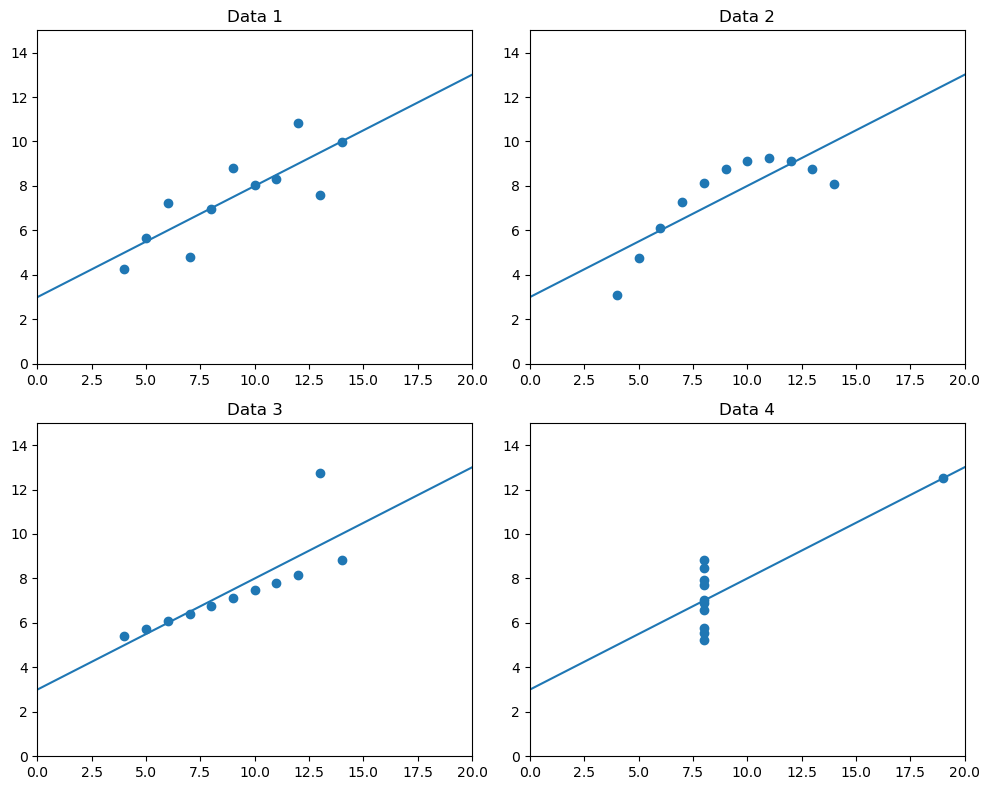

In [187]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].scatter(data1["wtf"], data1["shit"])

x_vals = np.linspace(0, 20, 100)
axes[0,0].plot(x_vals, a1*x_vals + b1)

axes[0,0].set_xlim(0,20)
axes[0,0].set_ylim(0,15)
axes[0,0].set_title("Data 1")

axes[0,1].scatter(data2["wtf"], data2["shit"])
axes[0,1].plot(x_vals, a2*x_vals + b2)

axes[0,1].set_xlim(0,20)
axes[0,1].set_ylim(0,15)
axes[0,1].set_title("Data 2")

axes[1,0].scatter(data3["wtf"], data3["shit"])
axes[1,0].plot(x_vals, a3*x_vals + b3)

axes[1,0].set_xlim(0,20)
axes[1,0].set_ylim(0,15)
axes[1,0].set_title("Data 3")

axes[1,1].scatter(data4["wtf"], data4["shit"])
axes[1,1].plot(x_vals, a4*x_vals + b4)

axes[1,1].set_xlim(0,20)
axes[1,1].set_ylim(0,15)
axes[1,1].set_title("Data 4")

plt.tight_layout()
plt.show()

# Part 4

# Part 5

## Exercise 5.2

In [188]:
focus_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1103369 entries, 0 to 3126837
Data columns (total 8 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   Incident Category     1103369 non-null  object        
 1   Incident Datetime     1103369 non-null  datetime64[ns]
 2   Incident Day of Week  1103369 non-null  object        
 3   Incident Code         1103369 non-null  int64         
 4   Incident Description  1103369 non-null  object        
 5   Police District       1103369 non-null  object        
 6   Longitude             1075084 non-null  float64       
 7   Latitude              1075084 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 75.8+ MB


In [ ]:
start_time = datetime.strptime('23:00', '%H:%M').time()
end_time = datetime.strptime('24:00', '%H:%M').time() if end_time != '24:00' else time(23, 59, 59)
start_date = pd.to_datetime('2018-03-01').date()
end_date = pd.to_datetime('2018-09-01').date()

len(focus_data[(focus_data['Incident Datetime'].dt.time >= start_time) & (focus_data['Incident Datetime'].dt.time <= end_time)
                & (focus_data['Incident Datetime'].dt.date >= start_date)
                & (focus_data['Incident Datetime'].dt.date <= end_date)])

1627

In [ ]:
# Get the times and count incidents between 11:00 and 12:00
time_counts = focus_df[(focus_df['Time'] >= start_time) & (focus_df['Time'] <= end_time)
                 & (focus_df['Incident Date'] >= start_date)
                  & (focus_df['Incident Date'] <= end_date)].groupby('Time').size()
times = time_counts.index

In [ ]:
# Create a figure
plt.figure(figsize=(12, 6))

def jitter_dots(dots):
    offsets = dots.get_offsets()
    jittered_offsets = offsets
    jittered_offsets[:, 0] += np.random.uniform(-0.3, 0.3, offsets.shape[0])
    dots.set_offsets(jittered_offsets)

# Create color array based on the counts
c = time_counts.values  # Use the actual counts for colors

# Plot each time point
for i, time in enumerate(times):
    dots = plt.scatter(np.full(1, i),  # Only one dot per time
                      time_counts[time],  # Y-value is the count
                      s=100,  # Made dots a bit larger
                      c=[time_counts[time]],  # Color based on count
                      cmap='plasma')
    jitter_dots(dots)

# Customize the plot
plt.xticks(range(len(times)), times, rotation=45)
xmin, xmax = plt.xlim()
plt.xlim(xmin - 0.3, xmax + 0.3)
plt.ylabel('Number of Crimes')
plt.title('Number of Crimes by Time')
cbar = plt.colorbar()
cbar.set_label('Number of Crimes')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# Print the actual counts for verification
print("\nCrime counts by time:")
print(time_counts)